In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [10]:
data = pd.read_csv("Healthcare_dataset.csv")
print(data.head())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

In [11]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [15]:
print(data.columns)

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data["Billing Amount Scaled"] = scaler.fit_transform(data[["Billing Amount"]])


In [29]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
data["Age Normalized"] = norm.fit_transform(data[["Age"]])

In [30]:
data = data.ffill()

In [31]:
data["Stay Duration"] = (data["Discharge Date"] - data["Date of Admission"]).dt.days

In [32]:
print(data.head())
print(data.info())

            Name  Age Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30      1         B-            Cancer        2024-01-31   
1   LesLie TErRy   62      1         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76      0         A-           Obesity        2022-09-22   
3   andrEw waTtS   28      0         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43      0        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306          

In [33]:
data.to_csv("standardized_healthcare_data.csv", index=False)

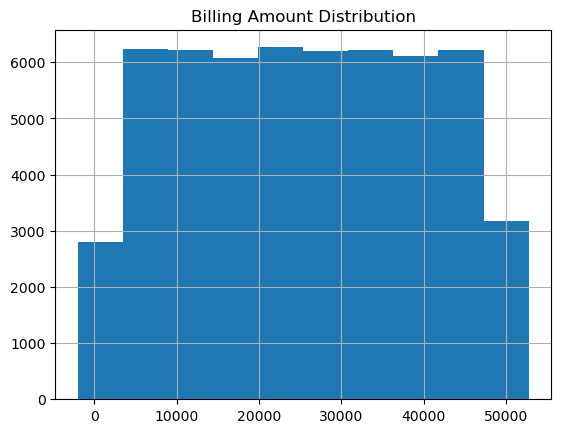

In [34]:
import matplotlib.pyplot as plt

data["Billing Amount"].hist()
plt.title("Billing Amount Distribution")
plt.show()

In [35]:
print(data["Stay Duration"].describe())

count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Stay Duration, dtype: float64


In [36]:
top_patients = data.sort_values(by="Billing Amount", ascending=False).head(5)
print(top_patients[["Name", "Billing Amount"]])

                   Name  Billing Amount
36349     tOdd CARrILlO    52764.276736
51313       kARen klInE    52373.032374
34613       kARen klInE    52373.032374
5735     DAVId SanDOvaL    52271.663747
7088   kathRYN GoNzales    52211.852966


In [41]:
print(data.groupby("Admission Type", observed=False)["Billing Amount"].mean())

Admission Type
Elective     25602.226311
Emergency    25497.397157
Urgent       25517.364497
Name: Billing Amount, dtype: float64


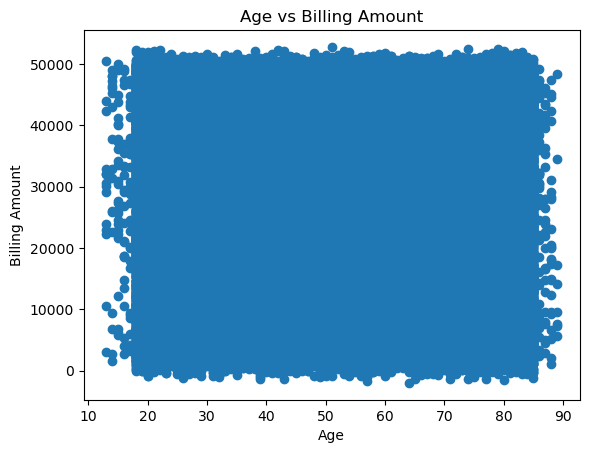

In [43]:
plt.scatter(data["Age"], data["Billing Amount"])
plt.title("Age vs Billing Amount")
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.show()

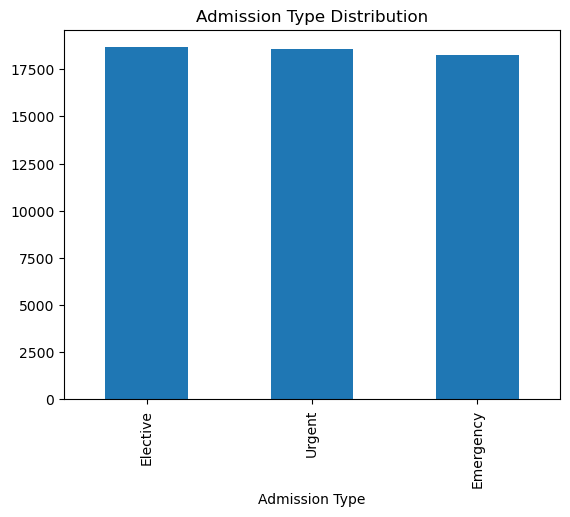

In [44]:
data["Admission Type"].value_counts().plot(kind="bar")
plt.title("Admission Type Distribution")
plt.show()